In [1]:
from astra import Astra, run_astra_with_distgen
from distgen import Generator
import os

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


# Distgen

In [2]:
distgen_input = '$LCLS_LATTICE/distgen/models/sc_inj/stanford/distgen.yaml'
G = Generator(distgen_input)
G['n_particle'] = 100000
G.run()
P0 = G.particles
P0

<ParticleGroup with 100000 particles at 0x1272385e0>

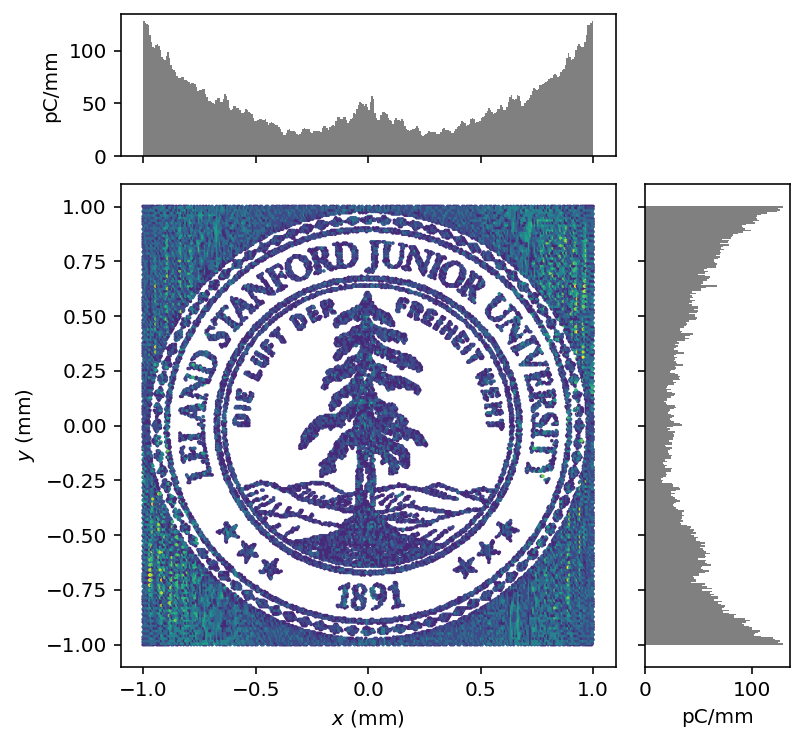

In [3]:
P0.plot('x', 'y', figsize=(6,6), bins=300)

# Astra

In [4]:
astra_input = os.path.expandvars('$LCLS_LATTICE/astra/models/sc_inj/v0/astra.in')

In [5]:
A = Astra(astra_input, initial_particles=P0)
A.verbose=False
A.input['charge']['lspch'] = False
A.input['output']['zstop'] = 1.49
A.input['output']['zemit'] = 100

In [6]:
%%time

BMAX = 0.1

A.input['solenoid']['maxb(2)'] = BMAX
A.input['solenoid']['maxb(3)'] = 0
A.run()

CPU times: user 2.38 s, sys: 232 ms, total: 2.62 s
Wall time: 50.3 s


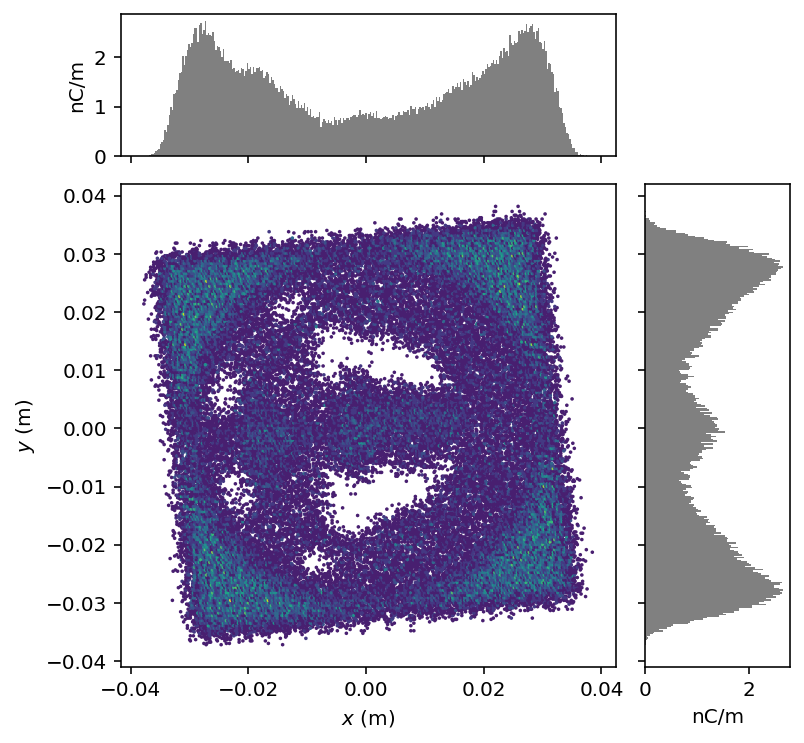

In [7]:
# No Space Charge
Pf = A.particles[-1]
Pf.plot('x', 'y', figsize=(6,6), bins=300)

In [8]:
%%time
A.input['charge']['lspch'] = True
A.run()

CPU times: user 2.28 s, sys: 186 ms, total: 2.47 s
Wall time: 9min 10s


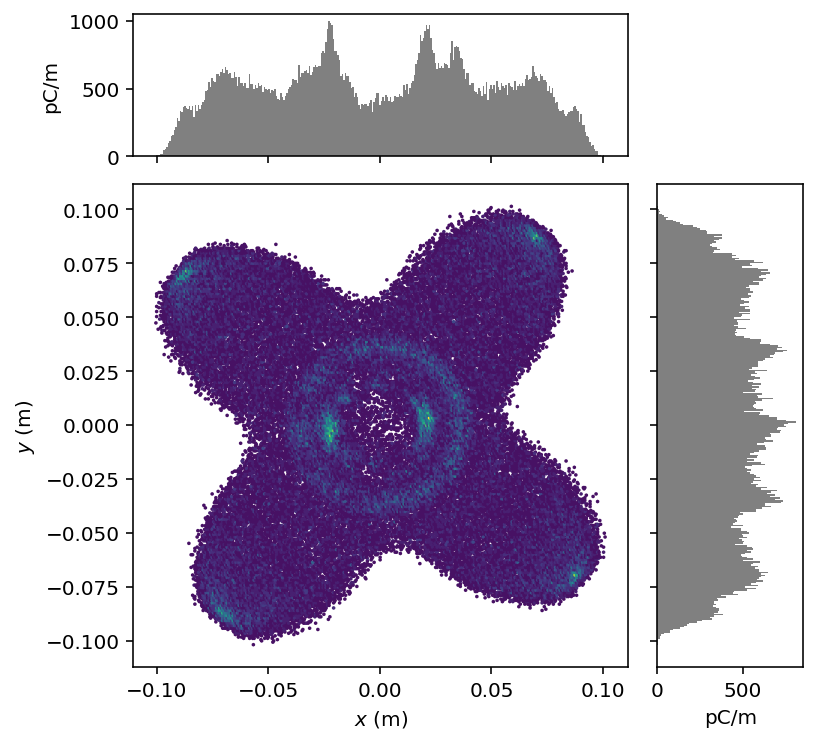

In [9]:
# With Space Charge
Pf = A.particles[-1]
Pf.plot('x', 'y', figsize=(6,6), bins=300)

## Field integrals and Larmor angle

In [10]:
A.input['solenoid']

{'lbfield': True,
 'file_bfield(1)': '/Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/realbucking.dat',
 'maxb(1)': 0,
 's_smooth(1)': 10,
 's_pos(1)': -0.062,
 's_xoff(1)': 0,
 's_yoff(1)': 0,
 's_higher_order(1)': True,
 'file_bfield(2)': '/Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/newSOL.dat',
 'maxb(2)': 0.1,
 's_smooth(2)': 10,
 's_pos(2)': 0.24653,
 's_xoff(2)': 0,
 's_yoff(2)': 0,
 's_higher_order(2)': True,
 'file_bfield(3)': '/Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/newSOL.dat',
 'maxb(3)': 0,
 's_smooth(3)': 10,
 's_pos(3)': 1.64581,
 's_xoff(3)': 0,
 's_yoff(3)': 0,
 's_higher_order(3)': True}

In [11]:
A.load_fieldmaps()
dat = A.fieldmap['newSOL.dat']['data']

In [12]:
z, Bz = dat.T
Bz /= Bz.max()
Bz *= BMAX

Text(0, 0.5, '$B_z$ (T)')

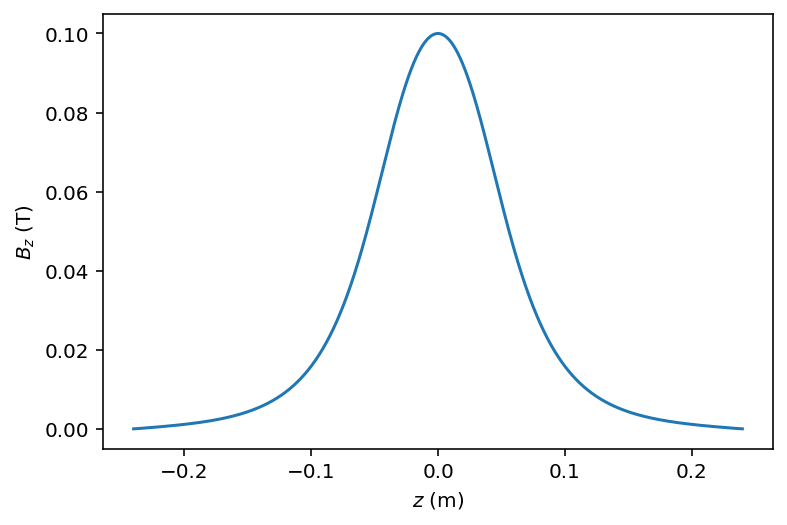

In [18]:
plt.plot(z, Bz)
plt.xlabel(r'$z$ (m)')
plt.ylabel(r'$B_z$ (T)')

In [14]:
# Integral B dz (T-m)
np.trapz(Bz, z)

0.012896517423475374

In [15]:
# Get the mean momentum in eV/c
c_light = 299792458.
p0 = Pf['mean_p']
p0

1219996.0805461684

In [16]:
# Larmor angle (deg)
-np.trapz(Bz, z) / (2*p0/c_light) * (180/np.pi)

-90.78777098491989